In [35]:
import numpy as np
import itertools
K = 6
# create systematic permutation of 6 tokens serially
permutations = np.array(list(itertools.permutations(range(K))))
print(permutations)


[[0 1 2 3 4 5]
 [0 1 2 3 5 4]
 [0 1 2 4 3 5]
 ...
 [5 4 3 1 2 0]
 [5 4 3 2 0 1]
 [5 4 3 2 1 0]]


In [36]:
from typing import List, Tuple, Dict
def calculate_position_distribution(functions: List) -> np.ndarray:
    """
    Calculate P(token at position) for all tokens and positions.
    Returns: K x K matrix where entry [i,j] = P(token i+1 at position j)
    """
    K = len(functions[0])
    dist = np.zeros((K, K))
    
    for function in functions:
        for pos, token in enumerate(function):
            dist[pos, token] += 1
    
    # Normalize by number of permutations
    dist = dist / len(functions)
    return dist

def calculate_pairwise_distribution(functions: List) -> np.ndarray:
        """
        Calculate P(token j follows token i) for all ordered pairs.
        Returns: K x K matrix where entry [i,j] = P(token j+1 follows token i+1)
        """
        K = len(functions[0])
        dist = np.zeros((K, K))
        
        for function in functions:
            for i in range(len(function) - 1):
                token_i = function[i]
                token_j = function[i+1]
                dist[token_i, token_j] += 1
        
        # Normalize by total number of adjacencies
        total_adjacencies = len(functions) * (K - 1)
        dist = dist / total_adjacencies
        return dist

In [37]:
def kl_divergence(p: np.ndarray, q: np.ndarray, epsilon: float = 1e-10) -> float:
    """
    Calculate KL divergence D_KL(P || Q).
    Add small epsilon to avoid log(0).
    """
    assert np.sum(p) == 1, "p must sum to 1"
    assert np.sum(q) == 1, "q must sum to 1"
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    return np.sum(p * np.log(p / q))

In [38]:
def kl_divergence_asymmetric(test_dist: np.ndarray, train_dist: np.ndarray, 
                                epsilon: float = 1e-10) -> float:
        """
        Calculate D_KL(Test || Train) - asymmetric divergence.
        
        Measures how much test distribution diverges from train.
        High values indicate test requires extrapolation beyond training coverage.
        
        Args:
            test_dist: Test distribution (P in KL formula)
            train_dist: Train distribution (Q in KL formula)
            epsilon: Small constant to handle zero probabilities
        
        Returns:
            KL divergence value
        """
        kl = 0.0
        flat_test = test_dist.flatten()
        flat_train = train_dist.flatten()
        
        for i in range(len(flat_test)):
            p_test = flat_test[i]
            p_train = flat_train[i]
            
            if p_test > epsilon:  # Only compute where test has mass
                if p_train < epsilon:  # Train has no coverage here - penalize heavily
                    kl += p_test * np.log(p_test / epsilon)
                else:
                    kl += p_test * np.log(p_test / p_train)
        
        return kl

In [3]:
train = permutations[:600]
test = permutations[600:]
print(len(train), len(test))



600 120


In [9]:
train_dist = calculate_position_distribution(train)
test_dist = calculate_position_distribution(test)
test_dist = np.array(test_dist)
train_dist = np.array(train_dist)
print(train_dist)
print(test_dist)


[[0.2  0.2  0.2  0.2  0.2  0.  ]
 [0.16 0.16 0.16 0.16 0.16 0.2 ]
 [0.16 0.16 0.16 0.16 0.16 0.2 ]
 [0.16 0.16 0.16 0.16 0.16 0.2 ]
 [0.16 0.16 0.16 0.16 0.16 0.2 ]
 [0.16 0.16 0.16 0.16 0.16 0.2 ]]
[[0.  0.  0.  0.  0.  1. ]
 [0.2 0.2 0.2 0.2 0.2 0. ]
 [0.2 0.2 0.2 0.2 0.2 0. ]
 [0.2 0.2 0.2 0.2 0.2 0. ]
 [0.2 0.2 0.2 0.2 0.2 0. ]
 [0.2 0.2 0.2 0.2 0.2 0. ]]


In [19]:
train_pairwise = calculate_pairwise_distribution(train)
test_pairwise = calculate_pairwise_distribution(test)
test_pairwise = np.array(test_pairwise)
train_pairwise = np.array(train_pairwise)
print(train_pairwise)
print(test_pairwise)

print(sum(sum(train_pairwise)))
print(sum(sum(test_pairwise)))

[[0.    0.032 0.032 0.032 0.032 0.04 ]
 [0.032 0.    0.032 0.032 0.032 0.04 ]
 [0.032 0.032 0.    0.032 0.032 0.04 ]
 [0.032 0.032 0.032 0.    0.032 0.04 ]
 [0.032 0.032 0.032 0.032 0.    0.04 ]
 [0.032 0.032 0.032 0.032 0.032 0.   ]]
[[0.   0.04 0.04 0.04 0.04 0.  ]
 [0.04 0.   0.04 0.04 0.04 0.  ]
 [0.04 0.04 0.   0.04 0.04 0.  ]
 [0.04 0.04 0.04 0.   0.04 0.  ]
 [0.04 0.04 0.04 0.04 0.   0.  ]
 [0.04 0.04 0.04 0.04 0.04 0.  ]]
1.0
1.0


In [16]:
kl_values = []
for i in range(K):
    kl_values.append(kl_divergence(test_dist[i, :], train_dist[i, :]))

print(kl_values)


kl_values_asymmetric = []
for i in range(K):
    kl_values_asymmetric.append(kl_divergence_asymmetric(test_dist[i, :], train_dist[i, :]))

print(kl_values_asymmetric)




[np.float64(23.025850907819322), np.float64(0.22314354902525418), np.float64(0.22314354902525418), np.float64(0.22314354902525418), np.float64(0.22314354902525418), np.float64(0.22314354902525418)]
[np.float64(23.025850929940457), np.float64(0.2231435513142098), np.float64(0.2231435513142098), np.float64(0.2231435513142098), np.float64(0.2231435513142098), np.float64(0.2231435513142098)]


In [23]:
kl_pairwise = []
for i in range(K):
    print(test_pairwise[i, :])
    print(train_pairwise[i, :])
    kl_pairwise.append(kl_divergence_asymmetric(test_pairwise[i, :], train_pairwise[i, :]))

print(sum(kl_pairwise)/K)
print(sum(test_pairwise.flatten()), sum(train_pairwise.flatten()))
print(kl_divergence(test_pairwise.flatten(), train_pairwise.flatten()))
print(kl_divergence_asymmetric(test_pairwise.flatten(), train_pairwise.flatten()))



[0.   0.04 0.04 0.04 0.04 0.  ]
[0.    0.032 0.032 0.032 0.032 0.04 ]
[0.04 0.   0.04 0.04 0.04 0.  ]
[0.032 0.    0.032 0.032 0.032 0.04 ]
[0.04 0.04 0.   0.04 0.04 0.  ]
[0.032 0.032 0.    0.032 0.032 0.04 ]
[0.04 0.04 0.04 0.   0.04 0.  ]
[0.032 0.032 0.032 0.    0.032 0.04 ]
[0.04 0.04 0.04 0.04 0.   0.  ]
[0.032 0.032 0.032 0.032 0.    0.04 ]
[0.04 0.04 0.04 0.04 0.04 0.  ]
[0.032 0.032 0.032 0.032 0.032 0.   ]
0.03719059188570163
1.0000000000000002 1.0000000000000004
0.22314354054026436
0.2231435513142097


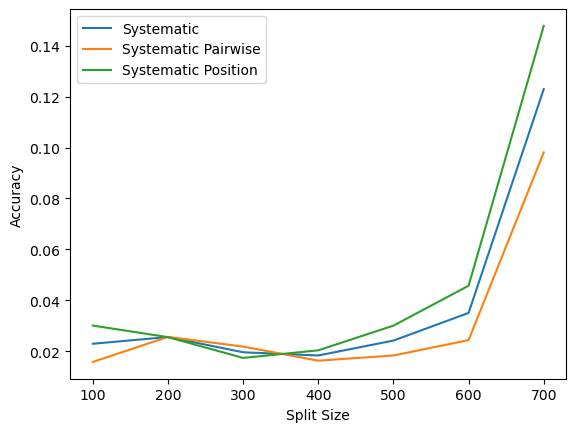

In [42]:
from matplotlib import pyplot as plt
import pickle
with open('/scratch4/workspace/ppruthi_umass_edu-CG/task_based_compositional_generalization/systematic_metrics.pkl', 'rb') as f:
    systematic_metrics = pickle.load(f)
with open('/scratch4/workspace/ppruthi_umass_edu-CG/task_based_compositional_generalization/random_metrics.pkl', 'rb') as f:
    random_metrics = pickle.load(f)
    
arr = random_metrics['step_by_step']['uniform']['abs']
x_values = [x[0] for x in arr][2:]
y_values = [x[1] for x in arr][2:]
y_pairwise_values = [x[2] for x in arr][2:]
y_position_values = [x[3] for x in arr][2:]


plt.plot(x_values, y_values, label='Systematic')
plt.plot(x_values, y_pairwise_values, label='Systematic Pairwise')
plt.plot(x_values, y_position_values, label='Systematic Position')
plt.xlabel('Split Size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
